In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [11]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -46.34925084214287 whereas concordance corr coef is 0.04052746426480818


In [12]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [13]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [14]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 0]], 'x_dev': x_dev_[:, [1, 3, 0]], 'x_test': x_test_[:, [1, 3, 0]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 0]], 'x_dev': x_dev_[:, [1, 3, 0]], 'x_test': x_test_[:, [1, 3, 0]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

y_train6_hh0 = y_train6 / x_train6_[:, 4]
y_train_hh0 = y_train / x_train_[:, 4]
y_dev_hh0 = y_dev / x_dev_[:, 4]
y_test_hh0 = y_test / x_test_[:, 4]

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 3), y_train shape: (52416,)
x_train6 shape: (10654, 3), y_train6 shape: (10654,)
x_dev shape: (9011, 3), y_dev shape: (9011,)
x_test shape: (16899, 3), y_test shape: (16899,)


In [15]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-hh0/6stations-hh0-nNPhi {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train6_[:, 4])
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 3.8975, MAE: 2.1930, R2: 0.7932, EVS: 0.7952, FIE_H: 0.2095, FIE_O: 0.3950, FIE_OH: 0.5426, LINCC: 0.8932
C01 » RMSE: 2.6212, MAE: 1.9280, R2: 0.8983, EVS: 0.8984, FIE_H: 0.1646, FIE_O: 0.3321, FIE_OH: 0.5008, LINCC: 0.9494
C01 » RMSE: 3.8534, MAE: 1.9801, R2: 0.8263, EVS: 0.8288, FIE_H: 0.2512, FIE_O: 0.4725, FIE_OH: 0.6313, LINCC: 0.9051
C02 » RMSE: 3.8843, MAE: 2.1294, R2: 0.7946, EVS: 0.7960, FIE_H: 0.2210, FIE_O: 0.4132, FIE_OH: 0.5712, LINCC: 0.8921
C02 » RMSE: 2.5292, MAE: 1.8502, R2: 0.9053, EVS: 0.9053, FIE_H: 0.1664, FIE_O: 0.3438, FIE_OH: 0.5173, LINCC: 0.9521
C02 » RMSE: 3.9648, MAE: 1.9855, R2: 0.8161, EVS: 0.8189, FIE_H: 0.2558, FIE_O: 0.4696, FIE_OH: 0.6250, LINCC: 0.8982
C03 » RMSE: 3.9520, MAE: 2.2565, R2: 0.7874, EVS: 0.7901, FIE_H: 0.2015, FIE_O: 0.3826, FIE_OH: 0.5248, LINCC: 0.8915
C03 » RMSE: 2.6194, MAE: 1.9528, R2: 0.8984, EVS: 0.8989, FIE_H: 0.1569, FIE_O: 0.3185, FIE_OH: 0.4834, LINCC: 0.9498
C03 » RMSE:

C24 » RMSE: 3.9350, MAE: 1.9735, R2: 0.8189, EVS: 0.8227, FIE_H: 0.2513, FIE_O: 0.4674, FIE_OH: 0.6362, LINCC: 0.9029
C25 » RMSE: 3.7845, MAE: 2.1378, R2: 0.8051, EVS: 0.8059, FIE_H: 0.2135, FIE_O: 0.4094, FIE_OH: 0.5638, LINCC: 0.8982
C25 » RMSE: 2.5862, MAE: 1.9192, R2: 0.9009, EVS: 0.9009, FIE_H: 0.1626, FIE_O: 0.3358, FIE_OH: 0.5008, LINCC: 0.9501
C25 » RMSE: 3.9548, MAE: 2.0149, R2: 0.8171, EVS: 0.8192, FIE_H: 0.2515, FIE_O: 0.4609, FIE_OH: 0.6152, LINCC: 0.8977
C26 » RMSE: 3.9837, MAE: 2.2295, R2: 0.7840, EVS: 0.7857, FIE_H: 0.2034, FIE_O: 0.3882, FIE_OH: 0.5429, LINCC: 0.8918
C26 » RMSE: 2.7136, MAE: 1.9947, R2: 0.8909, EVS: 0.8914, FIE_H: 0.1571, FIE_O: 0.3243, FIE_OH: 0.4903, LINCC: 0.9469
C26 » RMSE: 3.9133, MAE: 1.9781, R2: 0.8209, EVS: 0.8219, FIE_H: 0.2506, FIE_O: 0.4680, FIE_OH: 0.6316, LINCC: 0.9040
C27 » RMSE: 4.0141, MAE: 2.2107, R2: 0.7807, EVS: 0.7921, FIE_H: 0.2190, FIE_O: 0.4056, FIE_OH: 0.5517, LINCC: 0.8817
C27 » RMSE: 2.4946, MAE: 1.8108, R2: 0.9078, EVS: 0.9127

C48 » RMSE: 4.1147, MAE: 2.2169, R2: 0.7695, EVS: 0.7812, FIE_H: 0.2200, FIE_O: 0.4039, FIE_OH: 0.5560, LINCC: 0.8799
C48 » RMSE: 2.5594, MAE: 1.8343, R2: 0.9030, EVS: 0.9083, FIE_H: 0.1834, FIE_O: 0.3630, FIE_OH: 0.5224, LINCC: 0.9507
C48 » RMSE: 3.9075, MAE: 2.1000, R2: 0.8214, EVS: 0.8215, FIE_H: 0.2228, FIE_O: 0.4194, FIE_OH: 0.5765, LINCC: 0.9002
C49 » RMSE: 4.0498, MAE: 2.1734, R2: 0.7768, EVS: 0.7791, FIE_H: 0.2259, FIE_O: 0.4226, FIE_OH: 0.5720, LINCC: 0.8868
C49 » RMSE: 2.6364, MAE: 1.8645, R2: 0.8971, EVS: 0.8971, FIE_H: 0.1823, FIE_O: 0.3701, FIE_OH: 0.5260, LINCC: 0.9504
C49 » RMSE: 3.9592, MAE: 1.9244, R2: 0.8167, EVS: 0.8179, FIE_H: 0.2609, FIE_O: 0.4850, FIE_OH: 0.6453, LINCC: 0.9007
C50 » RMSE: 3.9771, MAE: 2.2368, R2: 0.7847, EVS: 0.7858, FIE_H: 0.2060, FIE_O: 0.3925, FIE_OH: 0.5364, LINCC: 0.8907
C50 » RMSE: 2.6621, MAE: 1.9931, R2: 0.8950, EVS: 0.8951, FIE_H: 0.1447, FIE_O: 0.3082, FIE_OH: 0.4702, LINCC: 0.9484
C50 » RMSE: 3.9353, MAE: 1.9376, R2: 0.8189, EVS: 0.8210

In [16]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-hh0/31stations-hh0-nNPhi {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train_[:, 4])
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 4.5420, MAE: 2.4772, R2: 0.7192, EVS: 0.7415, FIE_H: 0.2114, FIE_O: 0.3956, FIE_OH: 0.5391, LINCC: 0.8593
C01 » RMSE: 2.3440, MAE: 1.4965, R2: 0.9186, EVS: 0.9202, FIE_H: 0.2750, FIE_O: 0.5018, FIE_OH: 0.6701, LINCC: 0.9599
C01 » RMSE: 3.1276, MAE: 1.6963, R2: 0.8687, EVS: 0.8730, FIE_H: 0.2636, FIE_O: 0.4848, FIE_OH: 0.6482, LINCC: 0.9335
C02 » RMSE: 3.8879, MAE: 1.9658, R2: 0.7943, EVS: 0.7993, FIE_H: 0.2662, FIE_O: 0.4928, FIE_OH: 0.6514, LINCC: 0.8952
C02 » RMSE: 2.2035, MAE: 1.4556, R2: 0.9281, EVS: 0.9284, FIE_H: 0.2749, FIE_O: 0.5055, FIE_OH: 0.6693, LINCC: 0.9642
C02 » RMSE: 3.1130, MAE: 1.7074, R2: 0.8699, EVS: 0.8720, FIE_H: 0.2627, FIE_O: 0.4817, FIE_OH: 0.6420, LINCC: 0.9325
C03 » RMSE: 4.0676, MAE: 2.1604, R2: 0.7748, EVS: 0.7879, FIE_H: 0.2325, FIE_O: 0.4400, FIE_OH: 0.5964, LINCC: 0.8812
C03 » RMSE: 2.2506, MAE: 1.4670, R2: 0.9250, EVS: 0.9264, FIE_H: 0.2758, FIE_O: 0.5108, FIE_OH: 0.6728, LINCC: 0.9614
C03 » RMSE

C24 » RMSE: 2.2803, MAE: 1.5166, R2: 0.9230, EVS: 0.9234, FIE_H: 0.2636, FIE_O: 0.4852, FIE_OH: 0.6508, LINCC: 0.9609
C24 » RMSE: 3.0965, MAE: 1.7031, R2: 0.8713, EVS: 0.8735, FIE_H: 0.2644, FIE_O: 0.4830, FIE_OH: 0.6428, LINCC: 0.9321
C25 » RMSE: 4.0813, MAE: 2.0409, R2: 0.7733, EVS: 0.7790, FIE_H: 0.2630, FIE_O: 0.4819, FIE_OH: 0.6394, LINCC: 0.8835
C25 » RMSE: 2.3355, MAE: 1.5196, R2: 0.9192, EVS: 0.9201, FIE_H: 0.2663, FIE_O: 0.4957, FIE_OH: 0.6568, LINCC: 0.9595
C25 » RMSE: 3.0987, MAE: 1.6930, R2: 0.8711, EVS: 0.8724, FIE_H: 0.2665, FIE_O: 0.4862, FIE_OH: 0.6486, LINCC: 0.9320
C26 » RMSE: 4.1741, MAE: 2.0718, R2: 0.7628, EVS: 0.7716, FIE_H: 0.2626, FIE_O: 0.4867, FIE_OH: 0.6442, LINCC: 0.8809
C26 » RMSE: 2.3278, MAE: 1.4874, R2: 0.9198, EVS: 0.9207, FIE_H: 0.2748, FIE_O: 0.5065, FIE_OH: 0.6763, LINCC: 0.9606
C26 » RMSE: 3.1204, MAE: 1.6968, R2: 0.8693, EVS: 0.8713, FIE_H: 0.2630, FIE_O: 0.4846, FIE_OH: 0.6476, LINCC: 0.9334
C27 » RMSE: 3.9329, MAE: 1.9775, R2: 0.7895, EVS: 0.7935

C47 » RMSE: 3.0864, MAE: 1.6810, R2: 0.8721, EVS: 0.8729, FIE_H: 0.2660, FIE_O: 0.4902, FIE_OH: 0.6544, LINCC: 0.9322
C48 » RMSE: 4.1318, MAE: 2.1027, R2: 0.7676, EVS: 0.7795, FIE_H: 0.2465, FIE_O: 0.4680, FIE_OH: 0.6223, LINCC: 0.8813
C48 » RMSE: 2.2179, MAE: 1.4551, R2: 0.9272, EVS: 0.9288, FIE_H: 0.2650, FIE_O: 0.5042, FIE_OH: 0.6714, LINCC: 0.9633
C48 » RMSE: 3.0877, MAE: 1.6855, R2: 0.8720, EVS: 0.8737, FIE_H: 0.2661, FIE_O: 0.4900, FIE_OH: 0.6488, LINCC: 0.9332
C49 » RMSE: 4.2146, MAE: 2.2462, R2: 0.7582, EVS: 0.7783, FIE_H: 0.2216, FIE_O: 0.4208, FIE_OH: 0.5723, LINCC: 0.8720
C49 » RMSE: 2.2843, MAE: 1.4797, R2: 0.9227, EVS: 0.9274, FIE_H: 0.2819, FIE_O: 0.5109, FIE_OH: 0.6674, LINCC: 0.9598
C49 » RMSE: 3.0652, MAE: 1.7086, R2: 0.8738, EVS: 0.8740, FIE_H: 0.2581, FIE_O: 0.4736, FIE_OH: 0.6377, LINCC: 0.9320
C50 » RMSE: 3.9254, MAE: 2.0075, R2: 0.7903, EVS: 0.7947, FIE_H: 0.2634, FIE_O: 0.4830, FIE_OH: 0.6384, LINCC: 0.8920
C50 » RMSE: 2.3244, MAE: 1.5323, R2: 0.9200, EVS: 0.9206

In [17]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNPhi_hh0.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [11]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


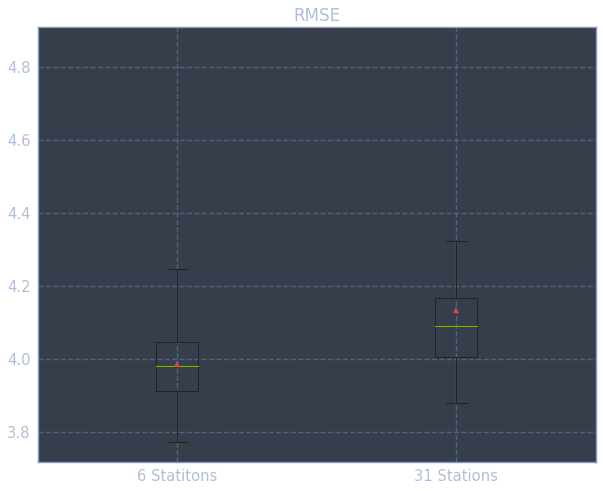

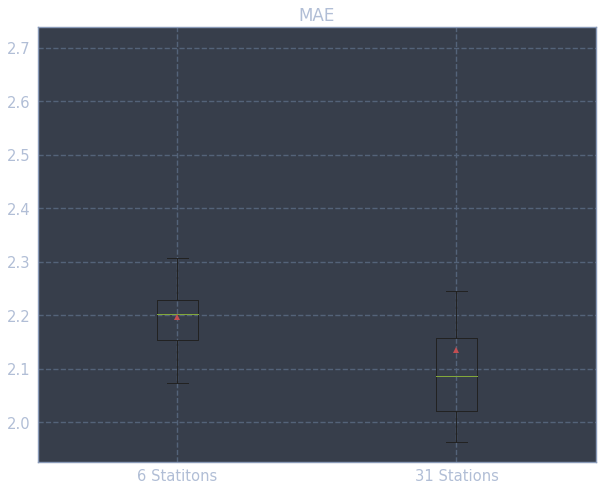

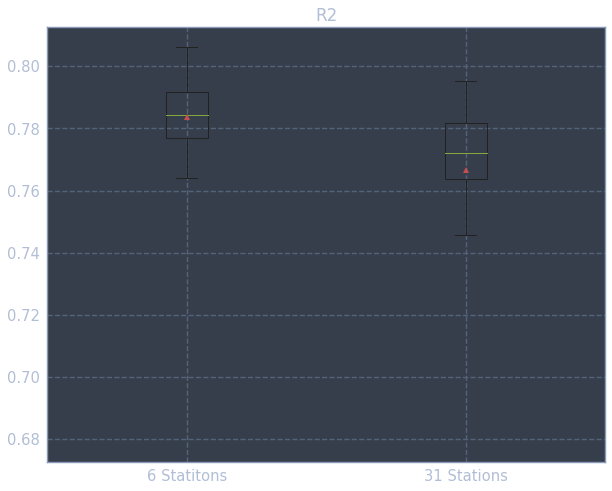

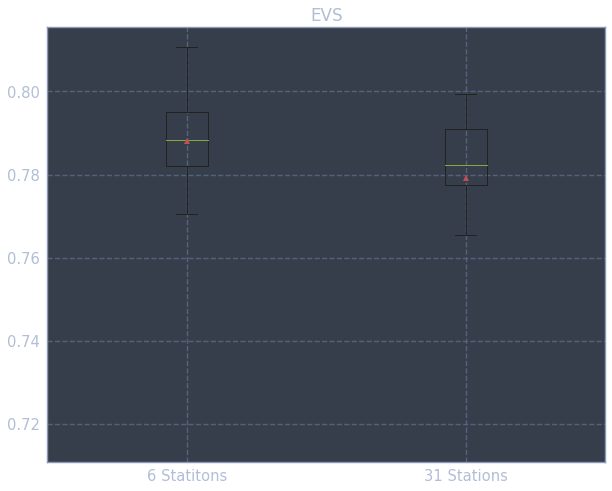

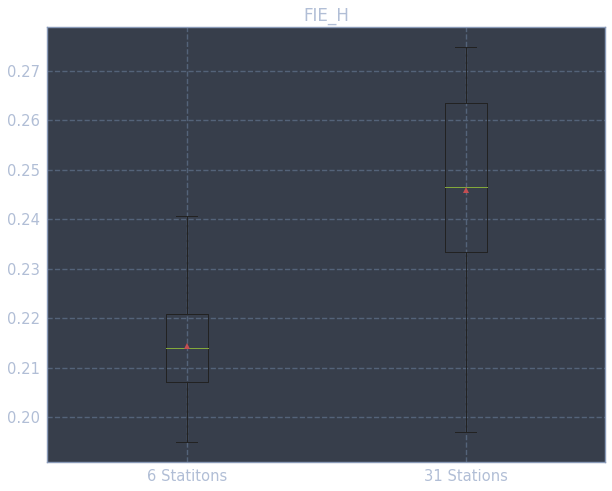

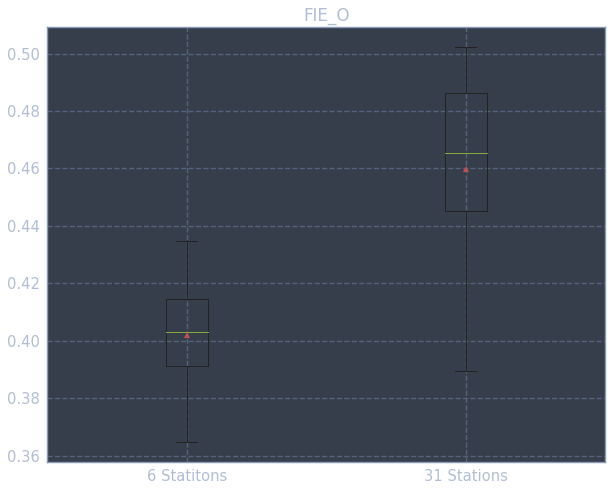

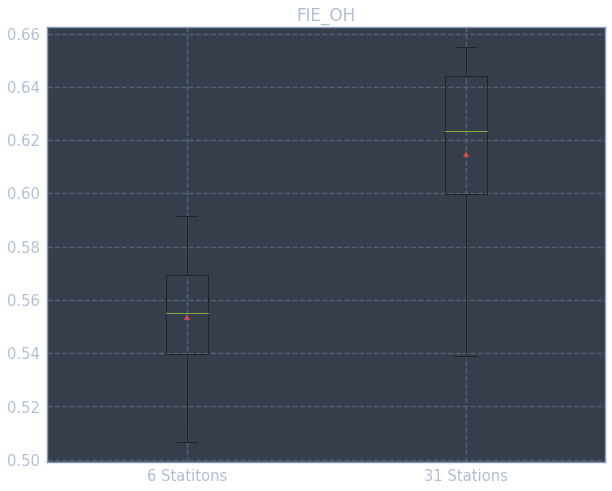

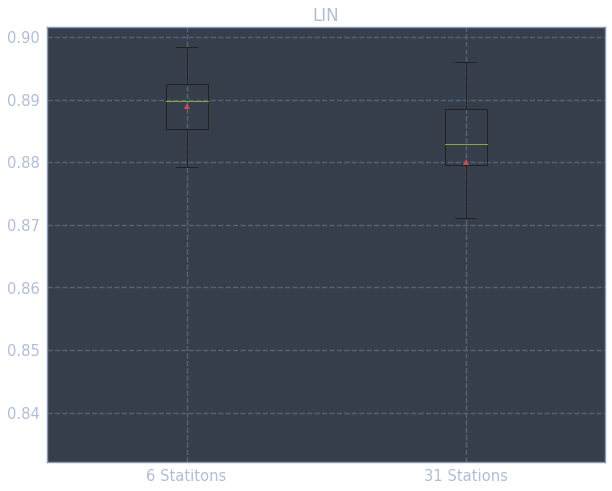

In [12]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1